Htet Khant Linn

Week 11

May 21, 2026



# Univariate

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./Solar_Data_Set.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8760 non-null   str    
 1   Solar Ir   8760 non-null   float64
dtypes: float64(1), str(1)
memory usage: 137.0 KB
None


In [17]:
df.dropna(inplace=True) # use this if df has null values

In [18]:
print(df.head(24))

              Date  Solar Ir 
0    1/1/2019 0:00   0.000000
1    1/1/2019 1:00   0.000000
2    1/1/2019 2:00   0.000000
3    1/1/2019 3:00   0.000000
4    1/1/2019 4:00   0.000000
5    1/1/2019 5:00   0.000000
6    1/1/2019 6:00   0.000000
7    1/1/2019 7:00   0.000000
8    1/1/2019 8:00   0.016447
9    1/1/2019 9:00   0.093861
10  1/1/2019 10:00   0.137033
11  1/1/2019 11:00   0.159210
12  1/1/2019 12:00   0.165264
13  1/1/2019 13:00   0.157040
14  1/1/2019 14:00   0.132158
15  1/1/2019 15:00   0.085159
16  1/1/2019 16:00   0.000000
17  1/1/2019 17:00   0.000000
18  1/1/2019 18:00   0.000000
19  1/1/2019 19:00   0.000000
20  1/1/2019 20:00   0.000000
21  1/1/2019 21:00   0.000000
22  1/1/2019 22:00   0.000000
23  1/1/2019 23:00   0.000000


In [19]:
one_day = df.iloc[0:24, 1].values
print(one_day)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.01644677 0.09386133 0.13703259 0.15921043
 0.1652641  0.15704037 0.13215804 0.08515894 0.         0.
 0.         0.         0.         0.         0.         0.        ]


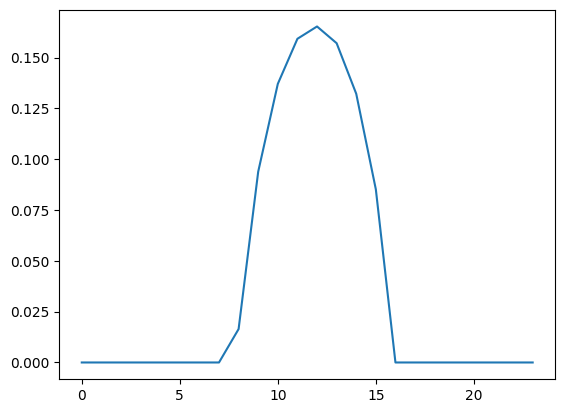

In [20]:
plt.plot(one_day)

In [21]:
training_set = df.iloc[:8712, 1:2].values
test_set = df.iloc[8712:, 1:2].values

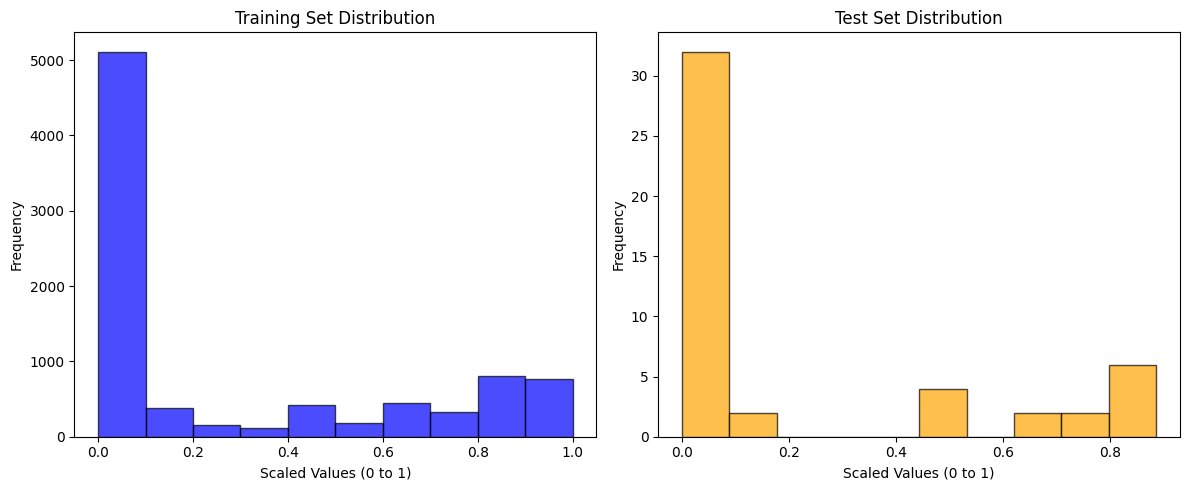

In [22]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0,1))

training_set_scaled = sc.fit_transform(training_set)
test_set_scaled = sc.transform(test_set)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes[0].hist(training_set_scaled, color = 'blue', edgecolor = 'black', alpha=0.7)
axes[0].set_title("Training Set Distribution")
axes[0].set_xlabel('Scaled Values (0 to 1)')
axes[0].set_ylabel('Frequency')


axes[1].hist(test_set_scaled, color = 'orange', edgecolor = 'black', alpha=0.7)
axes[1].set_title("Test Set Distribution")
axes[1].set_xlabel('Scaled Values (0 to 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [23]:
X_train = []
y_train = []
window_size = 24

for i in range(len(training_set_scaled) - window_size):
    X_train.append(training_set_scaled[i: i+window_size])
    y_train.append(training_set_scaled[i+window_size])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(8688, 24, 1)
(8688, 1)


In [24]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Dropout

In [25]:
Model_P = Sequential()

Model_P.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
Model_P.add(Dropout(0.2))

Model_P.add(LSTM(units=64, return_sequences=True))
Model_P.add(Dropout(0.2))

Model_P.add(LSTM(units=64, return_sequences=True))
Model_P.add(Dropout(0.2))

Model_P.add(LSTM(units=64))
Model_P.add(Dropout(0.2))

Model_P.add(Dense(units=1))

Model_P.compile(optimizer='adam', loss='mean_squared_error')
Model_P.fit(X_train, y_train, epochs=10, batch_size=32)

c:\Users\Aung Kaung Myat\miniconda3\envs\myenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - loss: 0.0271
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - loss: 0.0072
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 0.0059
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 0.0040
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 0.0028
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0026
Epoch 7/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - loss: 0.0019
Epoch 8/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 0.0019
Epoch 9/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0017
Epoch 10/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - loss: 0.0015


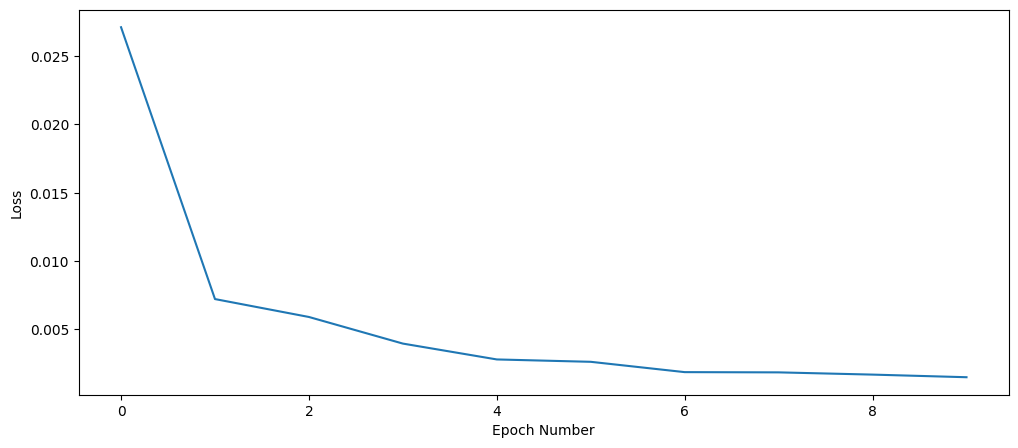

In [26]:
plt.figure(figsize=(12,5))
plt.plot(range(len(Model_P.history.history['loss'])), Model_P.history.history['loss'])
plt.xlabel("Epoch Number")
plt.ylabel("Loss")

plt.show()

In [27]:
prediction_test = []

Batch_one = training_set_scaled[-window_size:]
Batch_new = Batch_one.reshape((1, window_size, 1))

for i in range(len(test_set_scaled)):

    First_pred = Model_P.predict(Batch_new, verbose=0)[0]

    prediction_test.append(First_pred)

    Batch_new = np.append(
        Batch_new[:, 1:, :],
        [[First_pred]],
        axis=1
    )

prediction_test = np.array(prediction_test)

predictions = sc.inverse_transform(prediction_test)

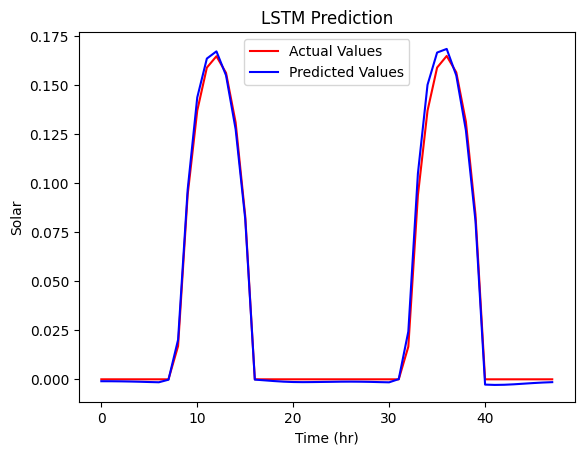

In [28]:
plt.plot(test_set, color='red', label='Actual Values')
plt.plot(predictions, color='blue', label='Predicted Values')
plt.title('LSTM Prediction')
plt.xlabel('Time (hr)')
plt.ylabel('Solar')
plt.legend()
plt.show()

In [29]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RMSE = math.sqrt(mean_absolute_error(test_set, predictions))
R_squared = r2_score(test_set, predictions)
MAE = mean_absolute_error(test_set, predictions)

print(f"RMSE : {RMSE}")
print(f"R_squared : {R_squared}")
print(f"MAE : {MAE}")


RMSE : 0.050554437333662855
R_squared : 0.9965134184754273
MAE : 0.0025557511341232444
